# EDA - Skincare Recommendation Chatbot
Eksplorasi data mentah sebelum cleaning, untuk 3 sumber:
- `raw_shopee_produk.csv`
- `raw_shopee_ulasan.csv`
- `review_skincare_x_*.csv`

Tujuan: ngerti struktur, missing values, duplikat, dan distribusi data sebelum diputusin cara cleaning-nya.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

plt.rcParams["figure.figsize"] = (8, 4)

produk = pd.read_csv("raw_shopee_produk.csv")
ulasan = pd.read_csv("raw_shopee_ulasan.csv")

x_files = list(Path(".").glob("review_skincare_x_*.csv"))
x_data = pd.read_csv(x_files[0], encoding="utf-8-sig") if x_files else None

print("produk:", produk.shape)
print("ulasan:", ulasan.shape)
print("x_data:", x_data.shape if x_data is not None else "tidak ditemukan")

produk: (1000, 7)
ulasan: (6059, 6)
x_data: (508, 12)


## 1. EDA - Data Produk (Shopee)

In [2]:
produk.info()
produk.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nama_produk  1000 non-null   str    
 1   harga        946 non-null    str    
 2   rating       854 non-null    float64
 3   terjual      854 non-null    str    
 4   link         1000 non-null   str    
 5   scraped_at   1000 non-null   str    
 6   sumber       1000 non-null   str    
dtypes: float64(1), str(6)
memory usage: 54.8 KB


,nama_produk,harga,rating,terjual,link,scraped_at,sumber
0,1. ELFORMULA Intensive Peeling Solution - Peel...,NaN,NaN,NaN,https://shopee.co.id/ELFORMULA-Intensive-Peeli...,2026-06-17T23:27:44.485073,shopee
1,2. SKIN1004 Madagascar Centella Tone Brighteni...,NaN,NaN,NaN,https://shopee.co.id/SKIN1004-Madagascar-Cente...,2026-06-17T23:27:45.123296,shopee
2,3. [BPOM] THE FACE Tamanu Essential Oil - Meng...,NaN,NaN,NaN,https://shopee.co.id/-BPOM-THE-FACE-Tamanu-Ess...,2026-06-17T23:27:45.821153,shopee
3,4. BIOAQUA Masker Komedo Bamboo Charcoal Black...,NaN,NaN,NaN,https://shopee.co.id/BIOAQUA-Masker-Komedo-Bam...,2026-06-17T23:27:46.408811,shopee
4,5. Bio Beauty Lab Luxurious Facial Oil Serum,NaN,NaN,NaN,https://shopee.co.id/Bio-Beauty-Lab-Luxurious-...,2026-06-17T23:27:46.951088,shopee


In [3]:
print("Missing values:")
print(produk.isna().sum())
print()
print("Duplikat berdasarkan link:", produk["link"].duplicated().sum())
print("Duplikat berdasarkan nama_produk:", produk["nama_produk"].duplicated().sum())

Missing values:
nama_produk      0
harga           54
rating         146
terjual        146
link             0
scraped_at       0
sumber           0
dtype: int64

Duplikat berdasarkan link: 1
Duplikat berdasarkan nama_produk: 0


In [4]:
# rating & terjual kosong bareng -> kemungkinan produk belum ada transaksi
kosong_bareng = produk["rating"].isna() & produk["terjual"].isna()
print(f"Baris rating & terjual kosong bareng: {kosong_bareng.sum()} dari {len(produk)}")

# harga kosong di awal data -> indikasi bug scraper di batch pertama
print("Baris harga kosong:", produk["harga"].isna().sum())
print("5 baris pertama yang harga-nya sudah terisi:")
produk[produk["harga"].notna()].head()

Baris rating & terjual kosong bareng: 146 dari 1000
Baris harga kosong: 54
5 baris pertama yang harga-nya sudah terisi:


,nama_produk,harga,rating,terjual,link,scraped_at,sumber
54,[FREE GIFT] The Originote Hyalucera Moisturize...,Rp42.000,NaN,NaN,https://shopee.co.id/-FREE-GIFT-The-Originote-...,2026-06-17T23:54:52.720078,shopee
55,[Hero] SCORA Tone Up Cream Series 30 Gr Tone U...,Rp34.900,NaN,NaN,https://shopee.co.id/-Hero-SCORA-Tone-Up-Cream...,2026-06-17T23:54:54.939138,shopee
56,Viva Sunscreen Foundation - UV FILTER (22 gr),Rp11.760,NaN,NaN,https://shopee.co.id/Viva-Sunscreen-Foundation...,2026-06-17T23:54:57.400089,shopee
57,𝐑𝐀𝐃𝐘𝐒𝐀 - BIOAQUA Sheet Mask Masker Wajah Buah ...,Rp4.500,NaN,NaN,https://shopee.co.id/%F0%9D%90%91%F0%9D%90%80%...,2026-06-17T23:54:59.484830,shopee
58,SCORA Toner Series 80ml - Hydra Calm Cica Tone...,Rp29.900,NaN,NaN,https://shopee.co.id/SCORA-Toner-Series-80ml-H...,2026-06-17T23:55:01.737852,shopee


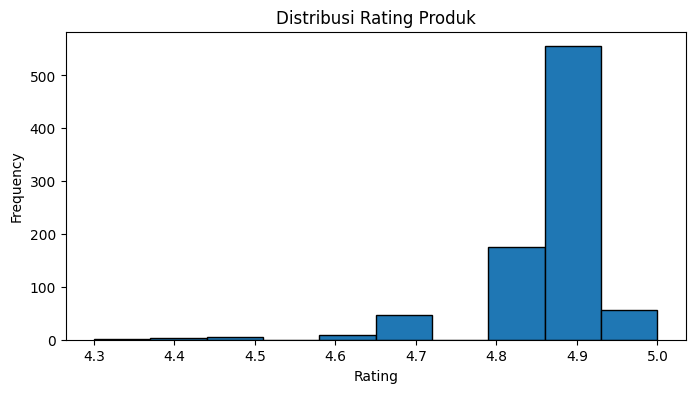

In [5]:
# distribusi rating produk (yang non-null)
fig, ax = plt.subplots()
produk["rating"].dropna().plot(kind="hist", bins=10, ax=ax, edgecolor="black")
ax.set_title("Distribusi Rating Produk")
ax.set_xlabel("Rating")
plt.show()

count    9.460000e+02
mean     1.129837e+06
std      3.251056e+07
min      6.210000e+02
25%      2.699925e+04
50%      4.794950e+04
75%      8.954925e+04
max      1.000000e+09
Name: harga, dtype: float64


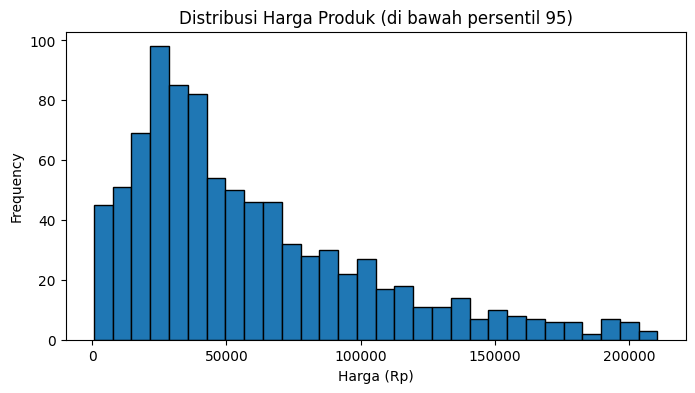

In [6]:
# distribusi harga (parsing sementara cuma buat eksplorasi visual)
def parse_harga_sementara(h):
    if not isinstance(h, str):
        return None
    digits = re.sub(r"[^\d]", "", h)
    return int(digits) if digits else None

harga_num = produk["harga"].apply(parse_harga_sementara).dropna()
print(harga_num.describe())

fig, ax = plt.subplots()
harga_num[harga_num < harga_num.quantile(0.95)].plot(kind="hist", bins=30, ax=ax, edgecolor="black")
ax.set_title("Distribusi Harga Produk (di bawah persentil 95)")
ax.set_xlabel("Harga (Rp)")
plt.show()

## 2. EDA - Data Ulasan (Shopee)

In [7]:
ulasan.info()
ulasan.head()

<class 'pandas.DataFrame'>
RangeIndex: 6059 entries, 0 to 6058
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   nama_produk  6059 non-null   str  
 1   link_produk  6059 non-null   str  
 2   teks_ulasan  6059 non-null   str  
 3   rating       6059 non-null   int64
 4   sumber       6059 non-null   str  
 5   scraped_at   6059 non-null   str  
dtypes: int64(1), str(5)
memory usage: 284.1 KB


,nama_produk,link_produk,teks_ulasan,rating,sumber,scraped_at
0,1. ELFORMULA Intensive Peeling Solution - Peel...,https://shopee.co.id/ELFORMULA-Intensive-Peeli...,Performa:bagus Cocok Untuk:memperbaiki skin ba...,5,shopee,2026-06-18T08:55:23.611014
1,1. ELFORMULA Intensive Peeling Solution - Peel...,https://shopee.co.id/ELFORMULA-Intensive-Peeli...,Efektivitas:sangat baik wajah bersih cerah Tek...,5,shopee,2026-06-18T08:55:23.611037
2,1. ELFORMULA Intensive Peeling Solution - Peel...,https://shopee.co.id/ELFORMULA-Intensive-Peeli...,Tekstur:liquid Performa:ok Cocok Untuk:all ski...,5,shopee,2026-06-18T08:55:23.611683
3,1. ELFORMULA Intensive Peeling Solution - Peel...,https://shopee.co.id/ELFORMULA-Intensive-Peeli...,Tekstur:agak kental dikit Daya serap:cepat mer...,5,shopee,2026-06-18T08:55:23.611703
4,1. ELFORMULA Intensive Peeling Solution - Peel...,https://shopee.co.id/ELFORMULA-Intensive-Peeli...,Tekstur:lembut Performa:baik Cocok Untuk:peeli...,5,shopee,2026-06-18T08:55:23.611711


In [8]:
print("Missing values:")
print(ulasan.isna().sum())
print()
print("Duplikat (nama_produk + teks_ulasan):",
      ulasan.duplicated(subset=["link_produk", "teks_ulasan"]).sum())

Missing values:
nama_produk    0
link_produk    0
teks_ulasan    0
rating         0
sumber         0
scraped_at     0
dtype: int64

Duplikat (nama_produk + teks_ulasan): 6


Distribusi rating ulasan (%):
rating
1     0.03
3     0.10
4     0.36
5    99.50
Name: proportion, dtype: float64


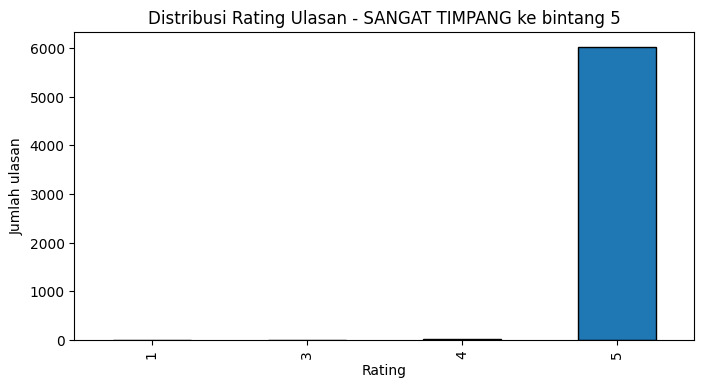

In [9]:
# ini temuan paling penting: skew rating ulasan
dist = ulasan["rating"].value_counts(normalize=True).sort_index() * 100
print("Distribusi rating ulasan (%):")
print(dist.round(2))

fig, ax = plt.subplots()
ulasan["rating"].value_counts().sort_index().plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("Distribusi Rating Ulasan - SANGAT TIMPANG ke bintang 5")
ax.set_xlabel("Rating")
ax.set_ylabel("Jumlah ulasan")
plt.show()

count    6059.000000
mean      211.724212
std       110.660752
min         6.000000
25%       139.000000
50%       198.000000
75%       261.000000
max      1723.000000
Name: teks_ulasan, dtype: float64


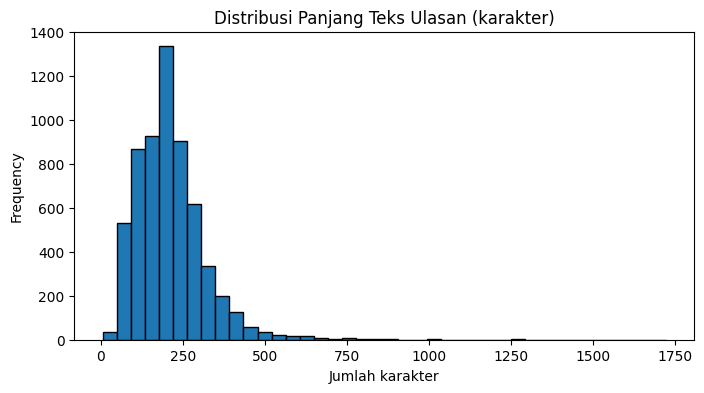

In [10]:
# panjang teks ulasan
panjang = ulasan["teks_ulasan"].dropna().str.len()
print(panjang.describe())

fig, ax = plt.subplots()
panjang.plot(kind="hist", bins=40, ax=ax, edgecolor="black")
ax.set_title("Distribusi Panjang Teks Ulasan (karakter)")
ax.set_xlabel("Jumlah karakter")
plt.show()

In [11]:
# cek pola label terstruktur (Tekstur:, Performa:, dll) yang ada di sebagian ulasan
contoh_label = ulasan[ulasan["teks_ulasan"].str.contains(":", na=False)]["teks_ulasan"].head(5)
for i, t in enumerate(contoh_label, 1):
    print(f"[{i}] {t}\n")

ada_label = ulasan["teks_ulasan"].str.contains(":", na=False).sum()
print(f"Ulasan yang mengandung label terstruktur: {ada_label} / {len(ulasan)}")

[1] Performa:bagus Cocok Untuk:memperbaiki skin barrier Tekstur:Kental  Udah 2 kali beli peeling solution dan setiap pakai kulit langsung glowing dan bersih apalagi awet sampai berbulan2 malahan di aku pakai 2 kali seminggu sampai 1 tahun lebih masyaallah  pengiriman nya pun aman bubble wrap nya tebal insyaallah selalu berlangganan utk pakai produk ini setiap exfoliasi

[2] Efektivitas:sangat baik wajah bersih cerah Tekstur:cair Daya serap:baik  Sudah beli kedua kalinya. Pengiriman cepat, untuk produk asli dan efektif mencerahkan menghaluskan mengurangi jerawat. Terima kasih

[3] Tekstur:liquid Performa:ok Cocok Untuk:all skin type  Ini BAGUS BANGET SIH!!! Ngga ada cekat cekitnya tapi tetep efektif but eksfo, the first time pake ini product muka ku langsung alus tanpa iritasi 😭😭😭

[4] Tekstur:agak kental dikit Daya serap:cepat meresap Efektivitas:kulit jadi cerah  produknya bagus bangetttt cocok di aku dn kulit ku sensitif tapi aku pkai produknya fine" aja malah tbah cerah dan muka ku 

## 3. EDA - Data X / Twitter

In [12]:
if x_data is not None:
    x_data.info()
    display(x_data.head())

<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   tweet_id          508 non-null    int64
 1   tanggal           508 non-null    str  
 2   username          508 non-null    str  
 3   teks              508 non-null    str  
 4   likes             508 non-null    int64
 5   retweets          508 non-null    int64
 6   replies           508 non-null    int64
 7   views             508 non-null    int64
 8   brand_disebut     508 non-null    str  
 9   sentimen          508 non-null    str  
 10  link_rekomendasi  508 non-null    str  
 11  url               508 non-null    str  
dtypes: int64(5), str(7)
memory usage: 47.8 KB


,tweet_id,tanggal,username,teks,likes,retweets,replies,views,brand_disebut,sentimen,link_rekomendasi,url
0,2072563389105389732,2026-07-02 06:09:52,879juta,@yappingfess kalau untuk skincare cocok cocoka...,0,0,0,14,-,positif,-,https://x.com/879juta/status/2072563389105389732
1,2072561794447790374,2026-07-02 06:03:32,jmverse__,"@tanyakanrl coba fokus basic skincare nder, ak...",0,0,0,14,"Azarine, Benton",positif,-,https://x.com/jmverse__/status/207256179444779...
2,2072561118766383362,2026-07-02 06:00:51,thruvsh,@MiskinTV_ memang anak jaman skrg itu mukany l...,0,0,0,28,-,positif,-,https://x.com/thruvsh/status/2072561118766383362
3,2072556923921301677,2026-07-02 05:44:11,sukaduittt__,Masih berjuang sama kulit berminyak dan jerawa...,0,0,1,69,Cosrx,positif,-,https://x.com/sukaduittt__/status/207255692392...
4,2072555309982503151,2026-07-02 05:37:46,bunnyell_,@womanfeeds_id skintint = make up tinted sunsc...,2,0,0,84,-,netral,-,https://x.com/bunnyell_/status/207255530998250...


In [13]:
if x_data is not None:
    print("Missing values:")
    print(x_data.isna().sum())
    print()
    print("Duplikat teks:", x_data["teks"].duplicated().sum())
    print("Jumlah baris dengan brand_disebut = '-':", (x_data["brand_disebut"] == "-").sum())

Missing values:
tweet_id            0
tanggal             0
username            0
teks                0
likes               0
retweets            0
replies             0
views               0
brand_disebut       0
sentimen            0
link_rekomendasi    0
url                 0
dtype: int64

Duplikat teks: 15
Jumlah baris dengan brand_disebut = '-': 313


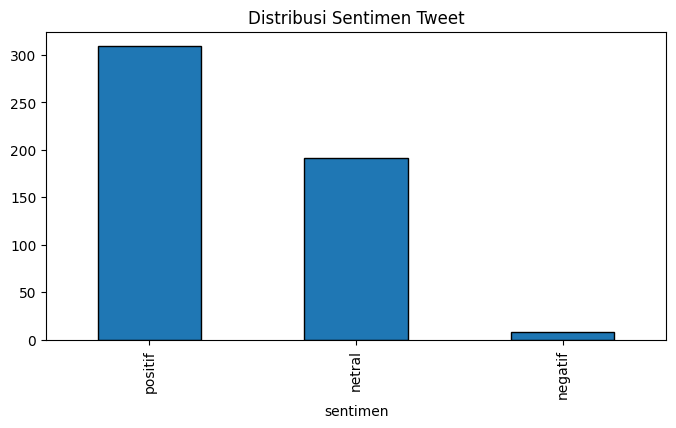

sentimen
positif    60.8
netral     37.6
negatif     1.6
Name: proportion, dtype: float64


In [14]:
if x_data is not None:
    fig, ax = plt.subplots()
    x_data["sentimen"].value_counts().plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title("Distribusi Sentimen Tweet")
    plt.show()

    print(x_data["sentimen"].value_counts(normalize=True).round(3) * 100)

brand_disebut
Wardah               93
Somethinc            46
Skintific            33
Cosrx                 5
Emina                 3
Innisfree             2
Avoskin               2
Wardah, Emina         2
Somethinc, Wardah     2
Azarine, Benton       1
Name: count, dtype: int64


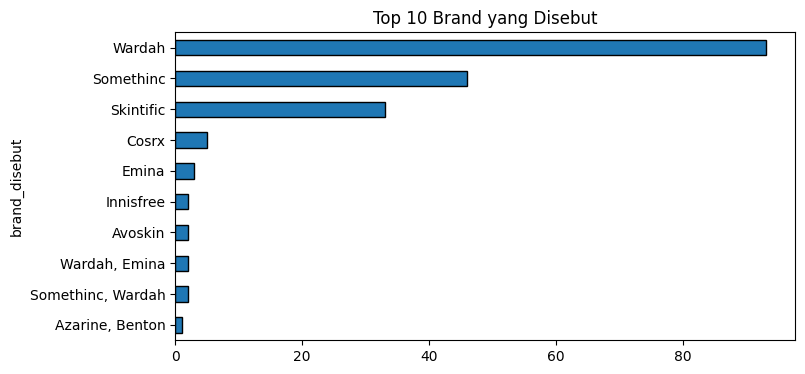

In [15]:
if x_data is not None:
    # brand yang paling sering disebut (exclude '-')
    brand_series = x_data[x_data["brand_disebut"] != "-"]["brand_disebut"]
    top_brand = brand_series.value_counts().head(10)
    print(top_brand)

    fig, ax = plt.subplots()
    top_brand.plot(kind="barh", ax=ax, edgecolor="black")
    ax.set_title("Top 10 Brand yang Disebut")
    ax.invert_yaxis()
    plt.show()

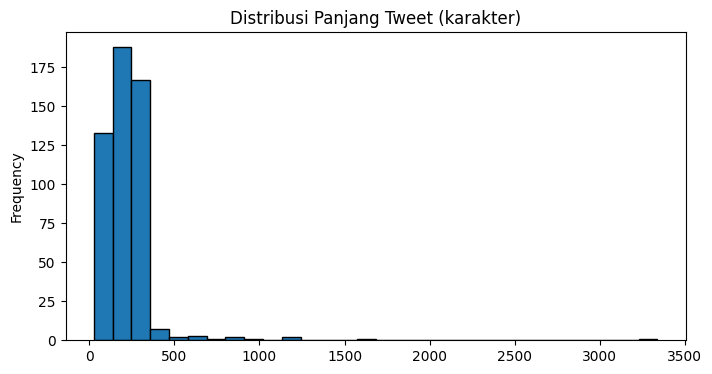

              likes      retweets      replies         views
count    508.000000    508.000000   508.000000  5.080000e+02
mean     302.265748     58.228346    18.608268  2.186457e+04
std     2489.416213    638.203701   119.694294  1.694788e+05
min        0.000000      0.000000     0.000000  1.000000e+00
25%        0.000000      0.000000     0.000000  4.000000e+01
50%        1.000000      0.000000     1.000000  2.595000e+02
75%        6.250000      1.000000     2.000000  1.957250e+03
max    40889.000000  13628.000000  1478.000000  3.071197e+06


In [16]:
if x_data is not None:
    fig, ax = plt.subplots()
    x_data["teks"].str.len().plot(kind="hist", bins=30, ax=ax, edgecolor="black")
    ax.set_title("Distribusi Panjang Tweet (karakter)")
    plt.show()

    print(x_data[["likes", "retweets", "replies", "views"]].describe())

### 3.1. Analisis Link dan Mention Shopee pada Data X

Mari kita hitung seberapa banyak data ulasan dari X yang memiliki tautan rekomendasi (affiliate link) atau menyebut Shopee di teks mereka.

In [17]:
if x_data is not None:
    # 1. Tweet yang memiliki link Shopee di kolom link_rekomendasi
    shopee_in_link = x_data["link_rekomendasi"].str.contains("shopee", case=False, na=False)
    
    # 2. Tweet yang menyebut 'shopee' di dalam teks tweet
    shopee_in_teks = x_data["teks"].str.contains("shopee", case=False, na=False)
    
    # 3. Total unik yang menyebut Shopee di teks ATAU link_rekomendasi
    shopee_any = shopee_in_link | shopee_in_teks
    
    print("=== ANALISIS LINK / MENTION SHOPEE ===")
    print(f"Jumlah tweet dengan link Shopee di 'link_rekomendasi': {shopee_in_link.sum()} dari {len(x_data)} ({shopee_in_link.mean()*100:.2f}%)")
    print(f"Jumlah tweet yang menyebut 'shopee' di kolom 'teks': {shopee_in_teks.sum()} dari {len(x_data)} ({shopee_in_teks.mean()*100:.2f}%)")
    print(f"Total tweet unik yang mention/merujuk ke Shopee (teks atau link): {shopee_any.sum()} dari {len(x_data)} ({shopee_any.mean()*100:.2f}%)")
    print("\nBeberapa contoh tweet yang merujuk ke Shopee:")
    display(x_data[shopee_any][["username", "teks", "link_rekomendasi"]].head(10))

=== ANALISIS LINK / MENTION SHOPEE ===
Jumlah tweet dengan link Shopee di 'link_rekomendasi': 61 dari 508 (12.01%)
Jumlah tweet yang menyebut 'shopee' di kolom 'teks': 19 dari 508 (3.74%)
Total tweet unik yang mention/merujuk ke Shopee (teks atau link): 70 dari 508 (13.78%)

Beberapa contoh tweet yang merujuk ke Shopee:


,username,teks,link_rekomendasi
21,dabeer_asif,"@qsenam Setuju banget, skincare lokal makin ba...",https://s.shopee.co.id/8fQQkJalNJ
29,starlitmxrklee,"yes, ini serum tint dengan 87% skincare ingred...",https://s.shopee.co.id/2BCwmPBNCA
39,nfselvaretta,"Selain gampang dibawa, travel kit ini juga coc...",https://s.shopee.co.id/2BCwhBvpg3
41,cookiesmounster,Pouch serut make up yang gak makan tempat kala...,https://s.shopee.co.id/3ViKGFEYbF
43,zylvechiasaras,ada gak sih rekomendasi skincare dan body care...,https://shopee.co.id/-BUY-3-GET-5-Hanasui-Glow...
44,luvmatchaasm,@yappingfess Aku ganti2 sih ka tp merk ini deb...,https://s.shopee.co.id/7AbcbV6YEP
57,marrmuudd,Udah berapa lama lo nggak ganti skincare yang ...,https://s.shopee.co.id/110yxRVP18
59,haulgirls,Wardah 💞 pict dari review shopee 🛒 https://t.c...,https://s.shopee.co.id/1gGfh5qL5T
60,9bintaa,— oh my glow calicylic acid https://t.co/LnwWu...,"https://s.shopee.co.id/AUs150fJQN, https://s.s..."
65,ratuchekout24,💜 COVER ME 3D FILTER BLUR 24H Soft-Filter Blur...,https://s.shopee.co.id/5L9wlQpyTR


## 4. Ringkasan Temuan EDA -> Dasar Keputusan Cleaning

**Data Produk**
- 1 duplikat link, ~145 produk tanpa rating/terjual (kemungkinan belum ada transaksi)
- 54 baris awal tanpa harga (indikasi bug scraper batch pertama)
- Nama produk masih ada prefix nomor urut

**Data Ulasan**
- Rating **99.5% bintang 5** -> perlu strategi khusus (stratified sampling) pas verifikasi manual & labeling sentimen, supaya kelas minoritas (rating rendah) ga hilang
- Sebagian ulasan punya label terstruktur (`Tekstur:`, `Performa:`, dll) yang bisa dipisah dari teks bebas, dibatasi oleh pola spasi ganda
- Ada duplikat ulasan antar baris

**Data X/Twitter**
- Sentimen juga timpang: mayoritas positif/netral, negatif cuma sedikit
- Ada BOM di header kolom pertama -> baca pakai `encoding="utf-8-sig"`
- `brand_disebut = "-"` berarti ga ada brand disebut, bukan brand bernama "-"
- Ada tweet duplikat
- Sebanyak 70 dari 508 tweet (13.78%) memiliki link rekomendasi ke Shopee (baik di kolom `link_rekomendasi` maupun di kolom `teks`)

Temuan-temuan ini yang jadi dasar logic di `clean_pipeline.py`.